In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from modules import *

dataset_path = './data/dataset.csv'

pipeline = PIACEIngestionPipeline(freq_minutes=5)
fe = PIACEFeatureEngineering(config_path="config/moduledb.json")
vis = DatasetVisualizer(config_path="config/moduledb.json")


In [2]:
# Cargar el dataset original
df_raw = pipeline.load_data(dataset_path)

print(df_raw.info())

<class 'pandas.DataFrame'>
RangeIndex: 75017 entries, 0 to 75016
Data columns (total 92 columns):
 #   Column                 Non-Null Count  Dtype
---  ------                 --------------  -----
 0   Time_Temp_A            70422 non-null  str  
 1   Temp_A                 70422 non-null  str  
 2   Time_Temp_B            71241 non-null  str  
 3   Temp_B                 71241 non-null  str  
 4   Time_Temp_C            68625 non-null  str  
 5   Temp_C                 68625 non-null  str  
 6   Time_Hum_A             25582 non-null  str  
 7   Hum_A                  25582 non-null  str  
 8   Time_Hum_B             24833 non-null  str  
 9   Hum_B                  24833 non-null  str  
 10  Time_Hum_C             24379 non-null  str  
 11  Hum_C                  24379 non-null  str  
 12  Time_Pres_A            74805 non-null  str  
 13  Pres_A                 74805 non-null  str  
 14  Time_Pres_B            74805 non-null  str  
 15  Pres_B                 74805 non-null  str  
 1

In [3]:
# 2. Resamplear y alinear todas las 46 señales a la grilla de 5 minutos de Time_CNA
df_resampled = pipeline.process_tag_series(df_raw, reference_time_col='Time_CNA', include_quality_flags=True)

print("Dimensiones tras resampleo:", df_resampled.shape)

display(df_resampled.head())

Dimensiones tras resampleo: (8641, 92)


,Temp_A,Temp_A_Has_Bad,Temp_B,Temp_B_Has_Bad,Temp_C,Temp_C_Has_Bad,Hum_A,Hum_A_Has_Bad,Hum_B,Hum_B_Has_Bad,...,Tag33_ACTIVA,Tag33_ACTIVA_Has_Bad,Tag34_ACTIVA,Tag34_ACTIVA_Has_Bad,Tag35_ACTIVA,Tag35_ACTIVA_Has_Bad,Tag36_ACTIVA,Tag36_ACTIVA_Has_Bad,CNA,CNA_Has_Bad
Timestamp,,,,,,,,,,,,,,,,,,,,,
2026-07-01 00:00:00,25.589476,0,25.707078,0,25.746826,0,NaN,0,NaN,0,...,502929.5,0,8915.0,0,272460.500000,0,11767.500000,0,346130.2853,0
2026-07-01 00:05:00,25.400115,0,25.517575,0,25.535419,0,95.420837,0,94.019600,0,...,712402.5,0,8954.5,0,231445.000000,0,11789.666667,0,350361.2279,0
2026-07-01 00:10:00,25.544410,0,25.640861,0,25.697656,0,94.763588,0,93.334053,0,...,708984.5,0,8965.0,0,349121.000000,0,11815.500000,0,349968.6748,0
2026-07-01 00:15:00,25.782943,0,25.974842,0,26.022270,0,NaN,0,NaN,0,...,572265.5,0,8872.5,0,332031.000000,0,11781.500000,0,345046.2714,0
2026-07-01 00:20:00,25.979138,0,26.091581,0,26.186801,0,94.002825,0,92.226969,0,...,665039.0,0,8842.5,0,270507.666667,0,11754.333333,0,346358.9946,0


In [4]:
# 3. Separar variables predictoras (X) y variable objetivo (y: estado Calc Failed)
X_raw = df_resampled.drop(columns=['CNA', 'CNA_Has_Bad'])
# 1 si CNA tuvo error o fue nulo, 0 si fue cálculo normal
y = ((df_resampled['CNA_Has_Bad'] == 1) | (df_resampled['CNA'].isna())).astype(int)

In [5]:
# 4. Extracción de características (Feature Engineering)
# Agrega estado de calidad, discrepancias A/B/C y condiciones de dominio
X = fe.transform(X_raw)
print("Dimensiones finales de X:", X.shape)
print("Distribución de la variable objetivo y (Calc Failed):", y.value_counts().to_dict())

Dimensiones finales de X: (8641, 107)
Distribución de la variable objetivo y (Calc Failed): {0: 8086, 1: 555}


In [6]:
# Comprobar las columnas QualityState generadas (0: Normal, 1: BAD, 2: Vacío)
qs_cols = [c for c in X.columns if c.endswith('_QualityState')]

# Ver distribución en algunas señales clave
for col in ['Temp_A_QualityState', 'Hum_A_QualityState', 'Tag1_QualityState', 'Tag2_QualityState']:
    print(f"{col}: {X[col].value_counts().to_dict()}")

# Visualizar las primeras filas de los estados
X[qs_cols].head()

Temp_A_QualityState: {0: 8639, 1: 1, 2: 1}
Hum_A_QualityState: {0: 7448, 2: 1192, 1: 1}
Tag1_QualityState: {0: 8595, 2: 45, 1: 1}
Tag2_QualityState: {0: 8222, 2: 418, 1: 1}


,Temp_A_QualityState,Temp_B_QualityState,Temp_C_QualityState,Hum_A_QualityState,Hum_B_QualityState,Hum_C_QualityState,Pres_A_QualityState,Pres_B_QualityState,Pres_C_QualityState,Tag1_QualityState,...,Tag27_QualityState,Tag28_QualityState,Tag29_QualityState,Tag30_QualityState,Tag31_ACTIVA_QualityState,Tag32_ACTIVA_QualityState,Tag33_ACTIVA_QualityState,Tag34_ACTIVA_QualityState,Tag35_ACTIVA_QualityState,Tag36_ACTIVA_QualityState
Timestamp,,,,,,,,,,,,,,,,,,,,,
2026-07-01 00:00:00,0,0,0,2,2,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2026-07-01 00:05:00,0,0,0,0,0,2,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2026-07-01 00:10:00,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2026-07-01 00:15:00,0,0,0,2,2,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2026-07-01 00:20:00,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [7]:
# Tabla comparativa ANTES vs DESPUÉS
display(vis.compare_pre_post(df_raw, X))

# Reporte estadístico preliminar (ejemplo de las primeras 10 señales)
display(vis.summarize_dataset(df_raw.iloc[:, :10]))
display(vis.summarize_dataset(X.iloc[:, :10]))

,Métrica,Antes (Dataset Crudo),Después (Resampleado a 5 min)
0,Total de Registros (Filas),"75,017 registros dispersos","8,641 intervalos regulares"
1,Total de Columnas,92 columnas (pares Time/Valor),107 señales unificadas
2,Tipo de Intervalo Temporal,"Irregular (por excepción, segundos/minutos)",Regular y continuo (exactamente 5 minutos)
3,Rango de Fechas,Desfasado entre sensores,2026-07-01 00:00:00 a 2026-07-31 00:00:00
4,Alineación entre Sensores,Desalineado (múltiples columnas de tiempo),Sincronizado en un solo Timestamp común
5,Trazabilidad de Errores BAD,"Textos de error mezclados ('Bad', 'Invalid Data')","Separado en Estados de Calidad (0, 1, 2)"


,Columna,Tipo,No_Nulos,Nulos,%_Nulos,Valores_Unicos,Media,Desv_Std,Min,Q1_25%,Mediana,Q3_75%,Max,Atipicos_IQR
0,Time_Temp_A,str,70422,4595,6.13,70422,46233.9989,0.0006,46233.9981,46233.9987,46233.9988,46233.9994,46233.9995,0
1,Temp_A,str,70422,4595,6.13,65914,27.8749,3.5971,22.1293,24.9573,26.8874,30.5425,37.2056,0
2,Time_Temp_B,str,71241,3776,5.03,71241,46233.9992,0.0006,46233.9984,46233.9990,46233.9991,46233.9996,46233.9998,0
3,Temp_B,str,71241,3776,5.03,66120,28.0961,3.7163,22.2260,25.0895,27.0176,30.8862,37.7609,0
4,Time_Temp_C,str,68625,6392,8.52,68625,46233.9989,0.0006,46233.9981,46233.9987,46233.9988,46233.9994,46233.9995,0
5,Temp_C,str,68625,6392,8.52,64358,28.0825,3.6914,22.1992,25.1067,27.0246,30.8322,37.6829,0
6,Time_Hum_A,str,25582,49435,65.90,25582,46233.9904,0.0057,46233.9818,46233.9874,46233.9926,46233.9949,46233.9952,0
7,Hum_A,str,25582,49435,65.90,25463,73.2750,15.4546,33.4239,61.1521,73.0821,86.9348,101.2179,0
8,Time_Hum_B,str,24833,50184,66.90,24833,46233.9855,0.0091,46233.9737,46233.9804,46233.9857,46233.9904,46233.9973,0
9,Hum_B,str,24833,50184,66.90,24730,69.6236,16.3110,27.8817,57.2061,69.1478,83.1762,100.0130,0


,Columna,Tipo,No_Nulos,Nulos,%_Nulos,Valores_Unicos,Media,Desv_Std,Min,Q1_25%,Mediana,Q3_75%,Max,Atipicos_IQR
0,Temp_A,float64,8641,0,0.0,8641,28.0552,3.6598,0.0000,25.0590,27.0762,30.9211,36.9752,1
1,Temp_B,float64,8641,0,0.0,8641,28.2395,3.7499,22.2786,25.1678,27.1886,31.1738,37.5999,0
2,Temp_C,float64,8641,0,0.0,8641,28.3018,3.7510,0.0000,25.2190,27.2862,31.2801,37.4656,1
3,Hum_A,float64,8641,0,0.0,7449,67.6391,31.2081,0.0000,56.4005,77.1966,92.4492,101.2179,1192
4,Hum_B,float64,8641,0,0.0,7409,65.1160,31.2281,0.0000,52.1253,74.3893,90.7857,100.0130,0
5,Hum_C,float64,8641,0,0.0,7516,66.4381,30.0602,0.0000,54.8205,75.3637,90.3209,99.2454,1122
6,Pres_A,float64,8641,0,0.0,8633,1.0034,0.0022,0.9968,1.0018,1.0036,1.0052,1.0084,0
7,Pres_B,float64,8641,0,0.0,8633,1.0020,0.0022,0.9956,1.0004,1.0022,1.0037,1.0069,0
8,Pres_C,float64,8641,0,0.0,8631,1.0018,0.0022,0.9953,1.0002,1.0020,1.0036,1.0070,0
9,Tag1,float64,8641,0,0.0,8465,33.4641,2.4228,0.0000,33.5828,33.6193,33.6733,34.0583,468


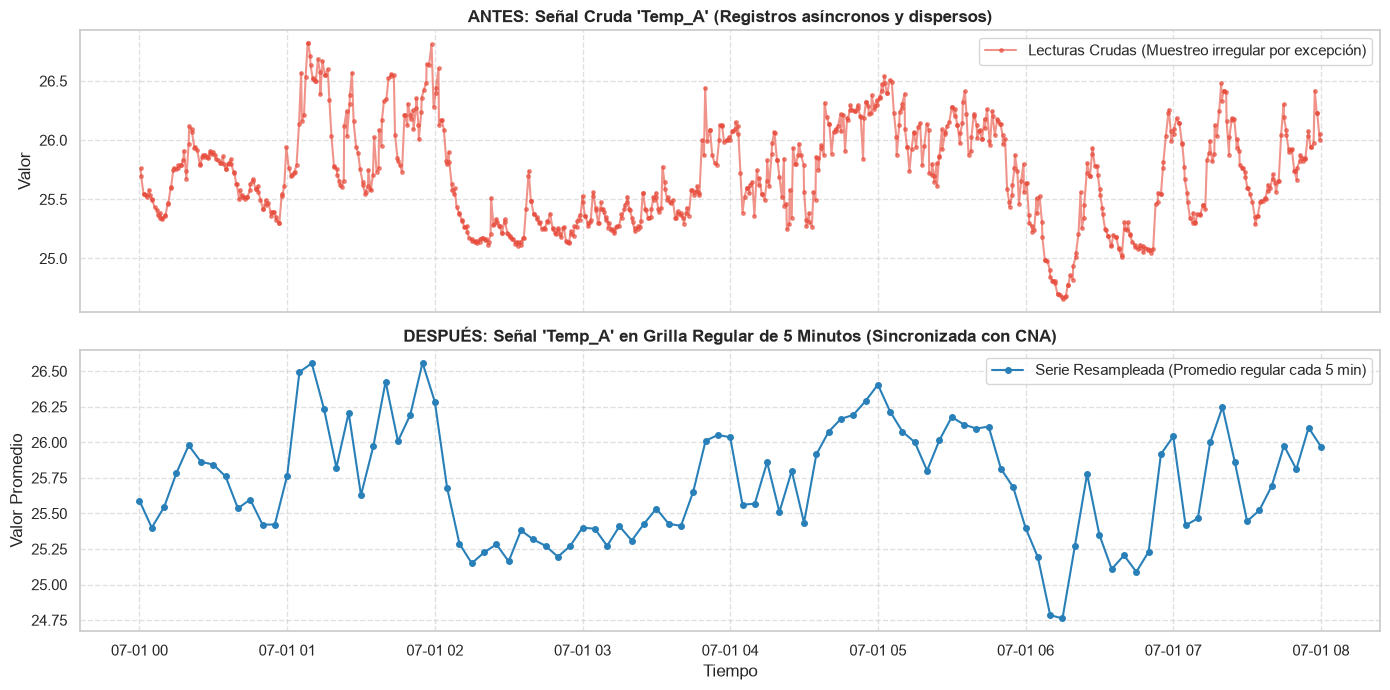

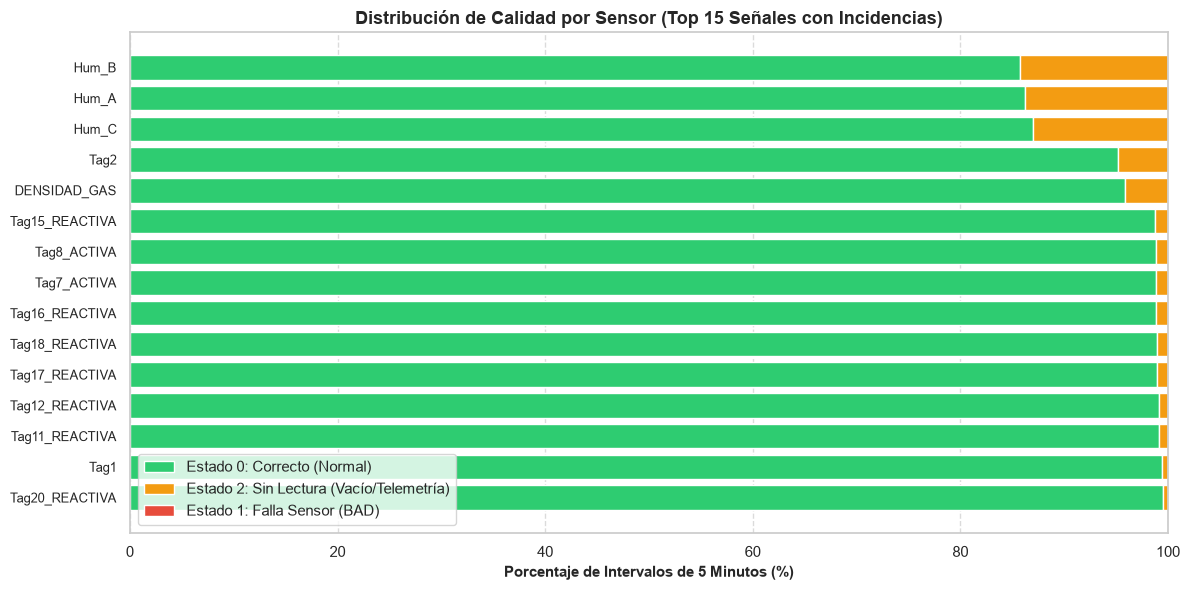

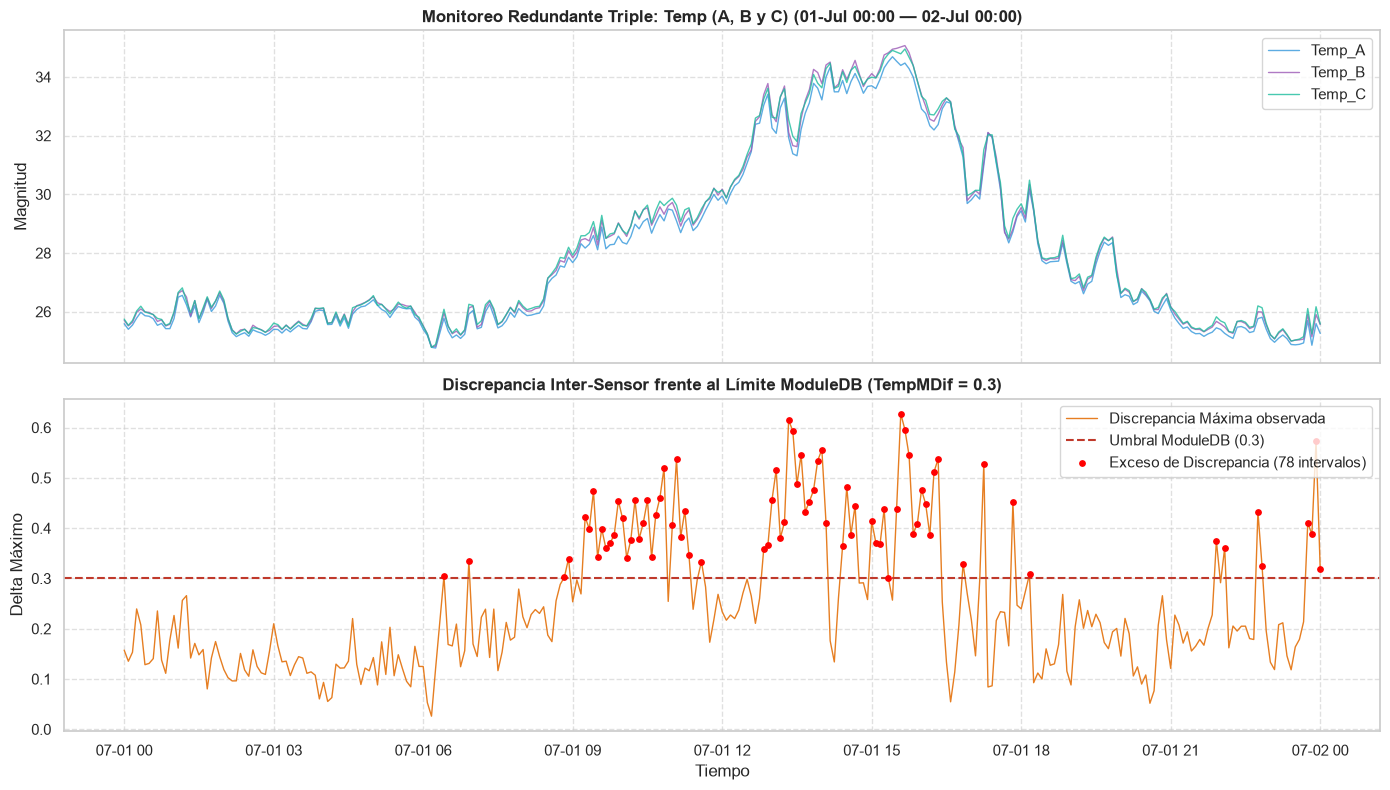

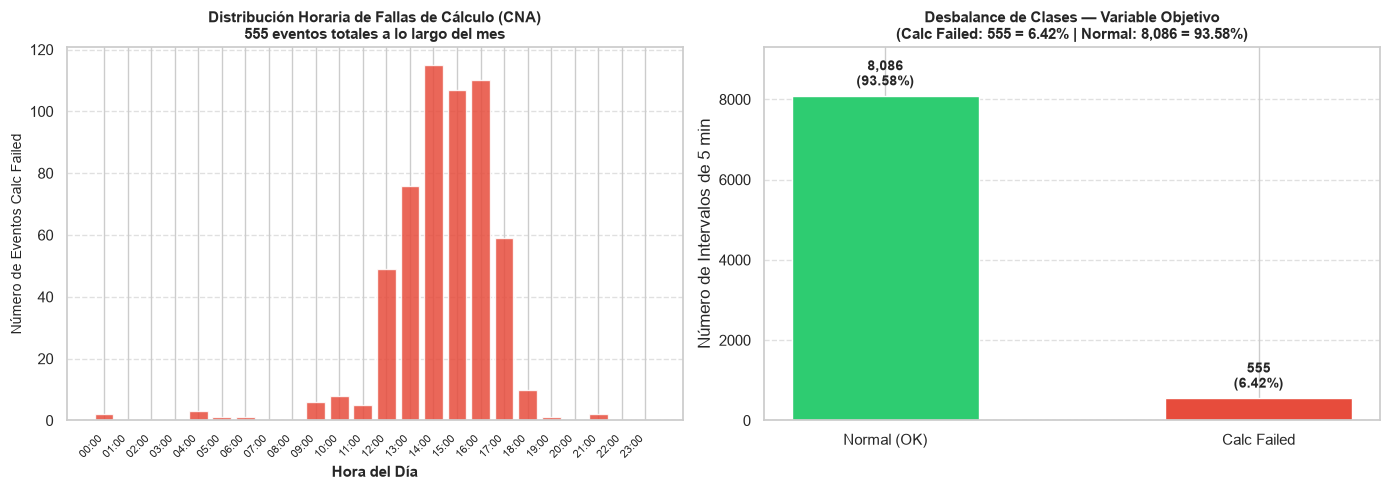

In [9]:
# Gráfica 1: Sincronización Temporal (Antes vs Después)
fig1, _ = vis.plot_resampling_comparison(df_raw, X, tag='Temp_A', sample_hours=8)
plt.show()

# Gráfica 2: Distribución de los 3 Estados de Calidad (0: Normal, 1: BAD, 2: Vacío)
fig2, _ = vis.plot_quality_distribution(X, top_n=15)
plt.show()

# Gráfica 3: Discrepancias Redundantes vs Umbral ModuleDB (Temperatura A, B y C)
fig3, _ = vis.plot_triple_redundancy(df_resampled, variable='Temp',sample_hours=24)
plt.show()

# Gráfica 4: Diagnóstico de la Variable Objetivo (CNA y Calc Failed)
fig4, _ = vis.plot_target_behavior(df_resampled, target_col='CNA')
plt.show()